# 22 - CNN Front-Only 4-Class

**Dataset:** Front-only 4-Class
**3 Skenario:** B1 (Baseline), B2 (Class Weights), B3 (Weights + Augmentasi)

In [1]:
import sys, os, json
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import DataLoader
from collections import Counter

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from training.models import EmotionCNN
from training.utils import (
    EmotionImageDataset, EmotionLandmarkDataset, EmotionMultimodalDataset,
    get_class_weights, train_model, full_evaluation,
    plot_training_history, plot_confusion_matrix, plot_per_class_f1
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)})")

Device: cuda
GPU: Tesla T4)


In [2]:
DATASET_DIR = PROJECT_ROOT / "data" / "dataset_frontonly_4class"
DATASET_AUG_DIR = PROJECT_ROOT / "data" / "dataset_frontonly_4class_augmented"
OUTPUT_DIR = PROJECT_ROOT / "models" / "frontonly" / "4class"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE = 32
EPOCHS = 50
LR = 0.0001
PATIENCE = 15
NUM_CLASSES = 4
EMOTIONS = ["neutral", "happy", "sad", "negative"]

print(f"Dataset: {DATASET_DIR}")
print(f"Output: {OUTPUT_DIR}")

Dataset: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_frontonly_4class
Output: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/4class


In [3]:
print("Loading image data...")
def load_dataloaders(dataset_dir, batch_size=32):
    train_ds = EmotionImageDataset(dataset_dir / "X_train_images.npy", dataset_dir / "y_train.npy")
    val_ds = EmotionImageDataset(dataset_dir / "X_val_images.npy", dataset_dir / "y_val.npy")
    test_ds = EmotionImageDataset(dataset_dir / "X_test_images.npy", dataset_dir / "y_test.npy")
    train_l = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_l = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_l = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    y = np.load(dataset_dir / "y_train.npy")
    counts = Counter(y.tolist())
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    for i, e in enumerate(EMOTIONS): print(f"  {e:>10s}: {counts.get(i, 0)}")
    return train_l, val_l, test_l

train_loader, val_loader, test_loader = load_dataloaders(DATASET_DIR, BATCH_SIZE)

Loading image data...


Train: 5348 | Val: 707 | Test: 1036
     neutral: 4192
       happy: 660
         sad: 382
    negative: 114


## Skenario B1: Baseline

Model parameters: 26,998,692

Training CNN B1 - Baseline (Front-Only)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      0.8644     0.7057     0.5619    0.9378   0.2421   0.000100  (35.9s)


     2      0.6231     0.7943     0.3999    0.9392   0.2770   0.000100  (35.4s)


     3      0.5784     0.8035     0.4067    0.9420   0.3186   0.000100  (35.1s)


     4      0.5410     0.8106     0.3787    0.9448   0.3543   0.000100  (34.6s)


...

    27      0.2218     0.9164     0.5862    0.7539   0.3314   0.000050  (33.7s)


    28      0.2161     0.9220     0.8806    0.6407   0.2944   0.000050  (33.6s)


    29      0.2073     0.9237     0.4767    0.8204   0.3446   0.000050  (33.7s)


    30      0.2052     0.9269     0.6572    0.7327   0.3199   0.000050  (33.6s)


    31      0.1965     0.9248     0.7572    0.6888   0.3214   0.000050  (33.6s)

Early stopping at epoch 31. Best epoch: 16 (val_f1=0.4432)

Best: epoch 16, val_acc=0.9279, val_f1=0.4432
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/4class/cnn_b1.pth


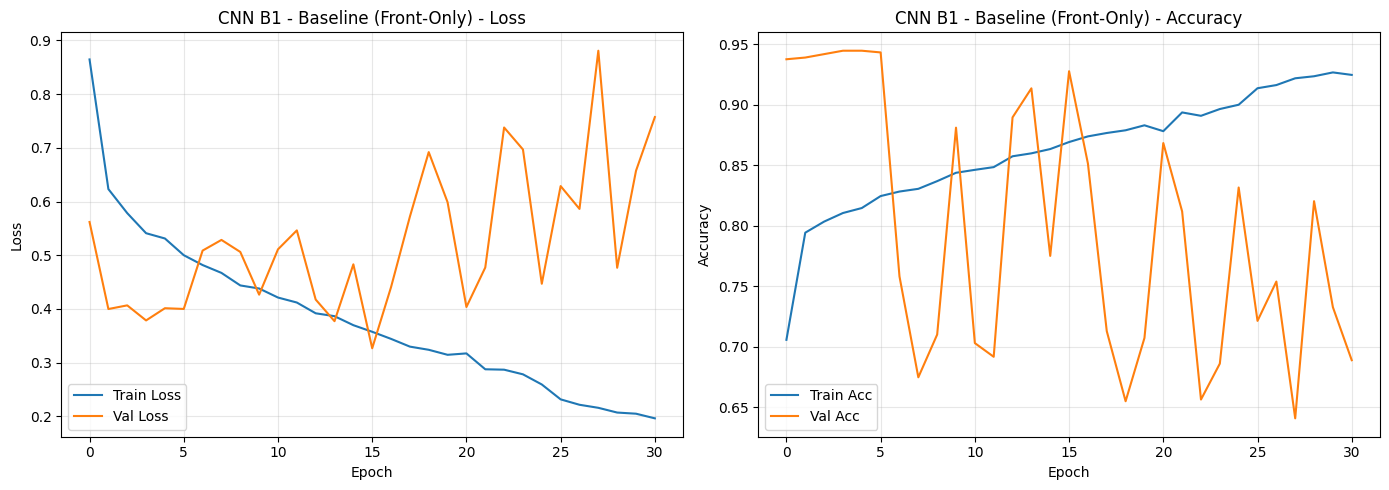

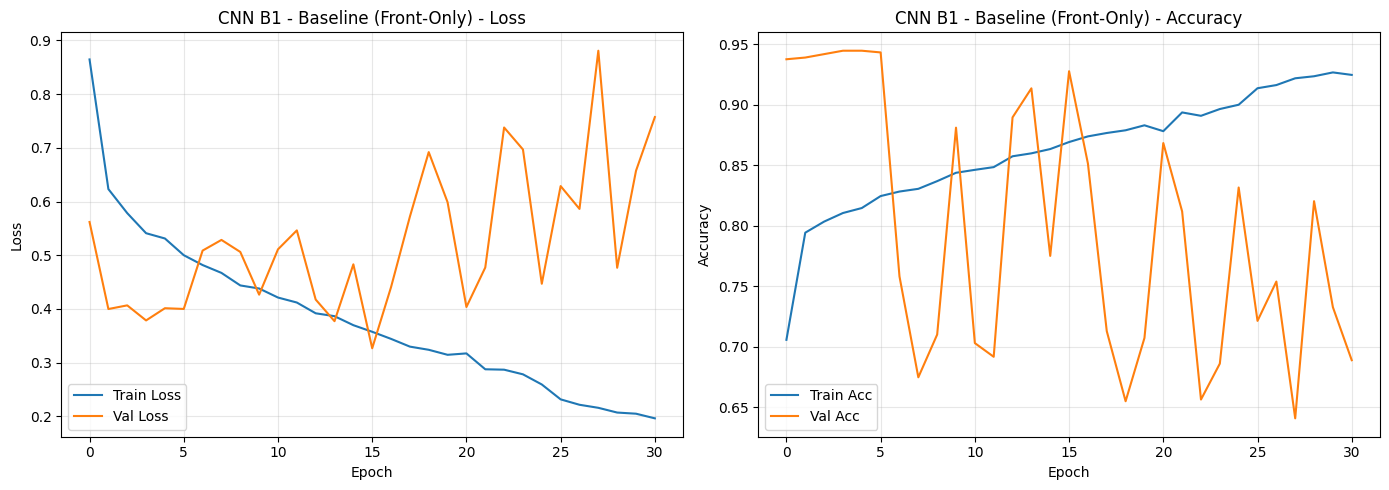

In [4]:
# B1: Baseline
criterion = nn.CrossEntropyLoss()

model = EmotionCNN(num_classes=NUM_CLASSES).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=8, min_lr=1e-7)

print("\nTraining CNN B1 - Baseline (Front-Only)...")
history, best_epoch = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler,
    device, model_type="cnn", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "cnn_b1.pth"))

plot_training_history(history, "CNN B1 - Baseline (Front-Only)")

EVALUASI B1 - BASELINE


Test Loss: 0.3851
Test Accuracy: 0.8929
Test Macro F1: 0.2379
Test Weighted F1: 0.9011

Classification Report:
              precision    recall  f1-score   support

     neutral       0.96      0.94      0.95       981
       happy       0.00      0.00      0.00        10
         sad       0.00      0.00      0.00        29
    negative       0.00      0.00      0.00        16

    accuracy                           0.89      1036
   macro avg       0.24      0.24      0.24      1036
weighted avg       0.91      0.89      0.90      1036



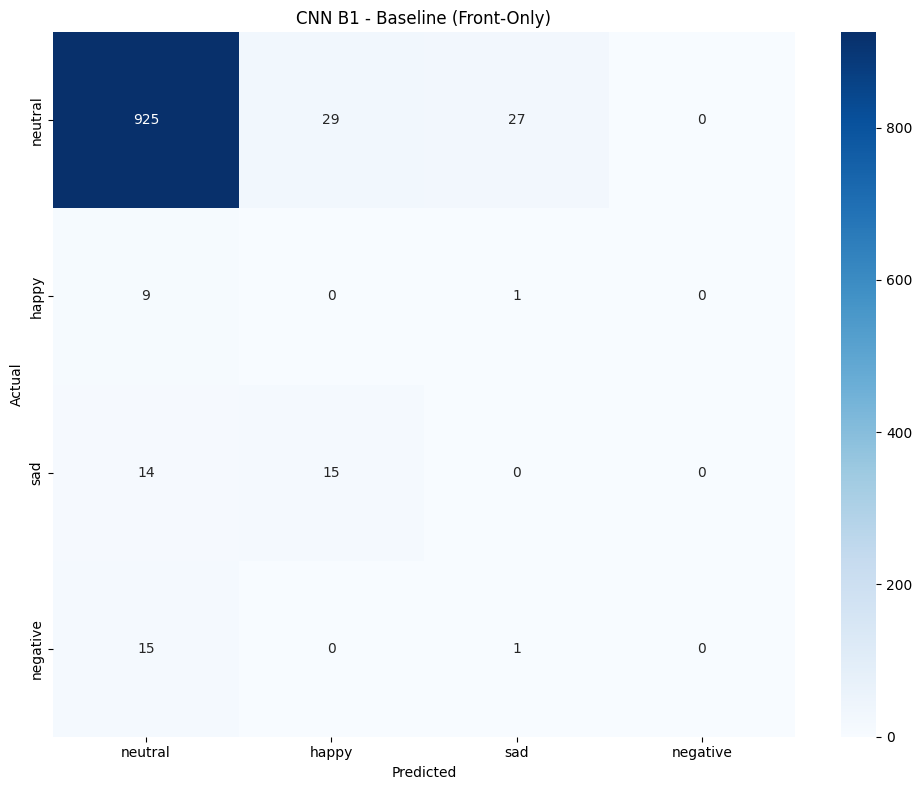

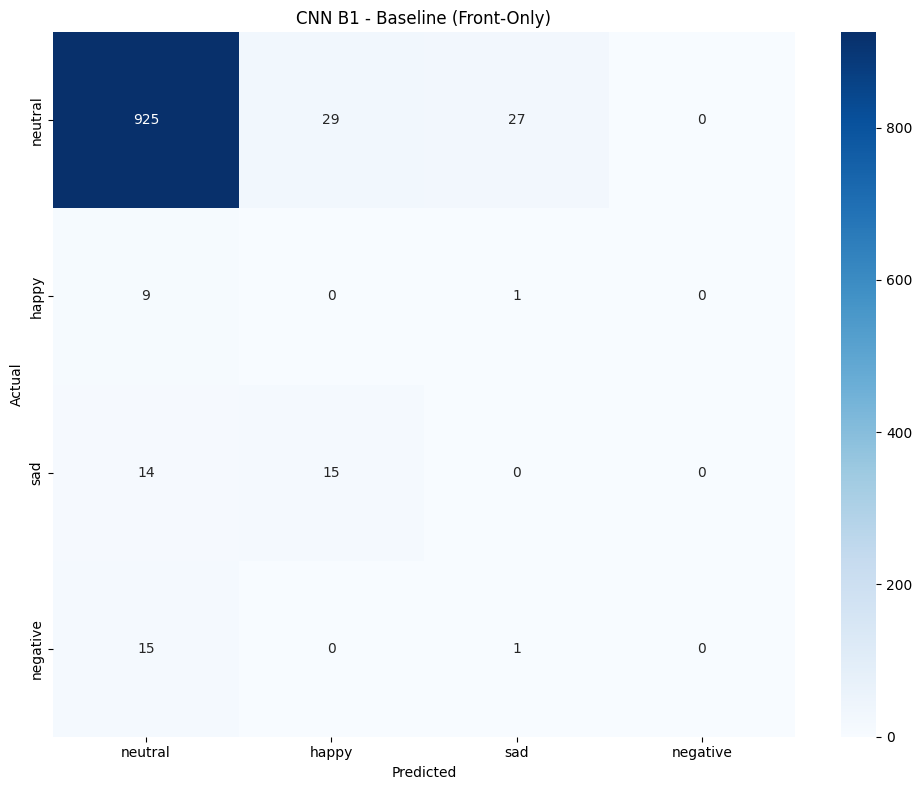

In [5]:
# Evaluate B1
model.load_state_dict(torch.load(OUTPUT_DIR / "cnn_b1.pth", map_location=device, weights_only=True))
print("=" * 60)
print("EVALUASI B1 - BASELINE")
print("=" * 60)
results_b1 = full_evaluation(model, test_loader, criterion, device, "cnn", EMOTIONS)
plot_confusion_matrix(results_b1["confusion_matrix"], "CNN B1 - Baseline (Front-Only)", emotions=EMOTIONS)

## Skenario B2: Class Weights

Class weights: None


Model parameters: 26,998,692

Training CNN B2 - Class Weights (Front-Only)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      0.9957     0.6251     0.5492    0.9378   0.2420   0.000100  (33.6s)


     2      0.6525     0.7945     0.4438    0.9406   0.2808   0.000100  (33.5s)


     3      0.5822     0.8018     0.5644    0.8345   0.2644   0.000100  (33.5s)


...

    24      0.2631     0.9045     0.5943    0.7298   0.3069   0.000050  (33.6s)


    25      0.2511     0.9080     0.4005    0.8868   0.3743   0.000050  (33.5s)


    26      0.2495     0.9069     0.4610    0.8557   0.3481   0.000050  (33.7s)


    27      0.2388     0.9132     0.6526    0.7100   0.3016   0.000050  (33.6s)


    28      0.2238     0.9181     0.5620    0.7808   0.3237   0.000050  (33.7s)

Early stopping at epoch 28. Best epoch: 13 (val_f1=0.3780)

Best: epoch 13, val_acc=0.8501, val_f1=0.3780
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/4class/cnn_b2.pth


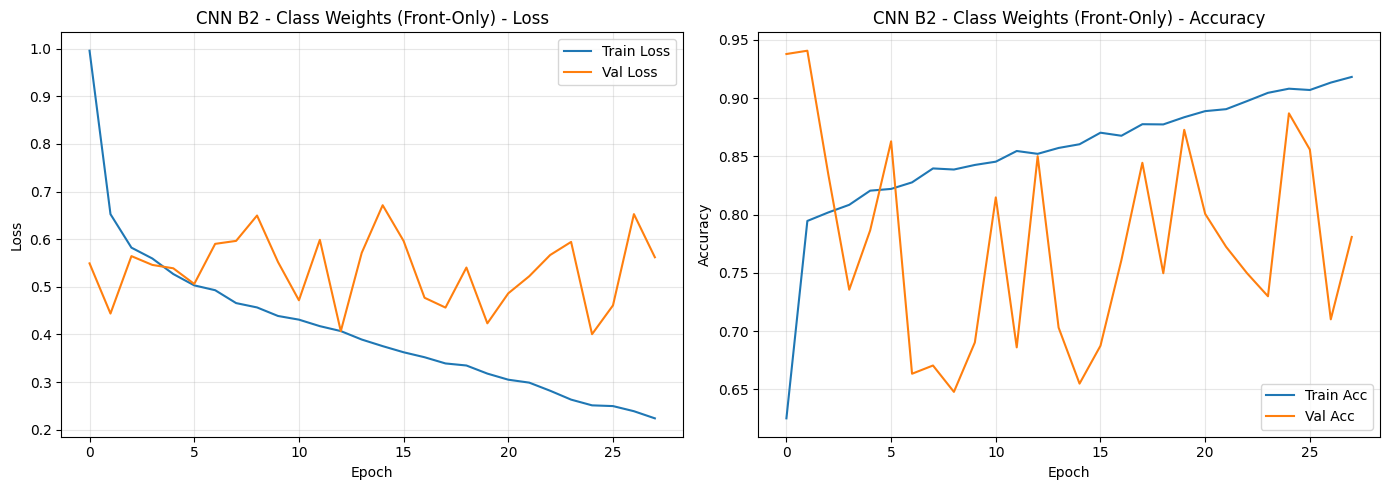

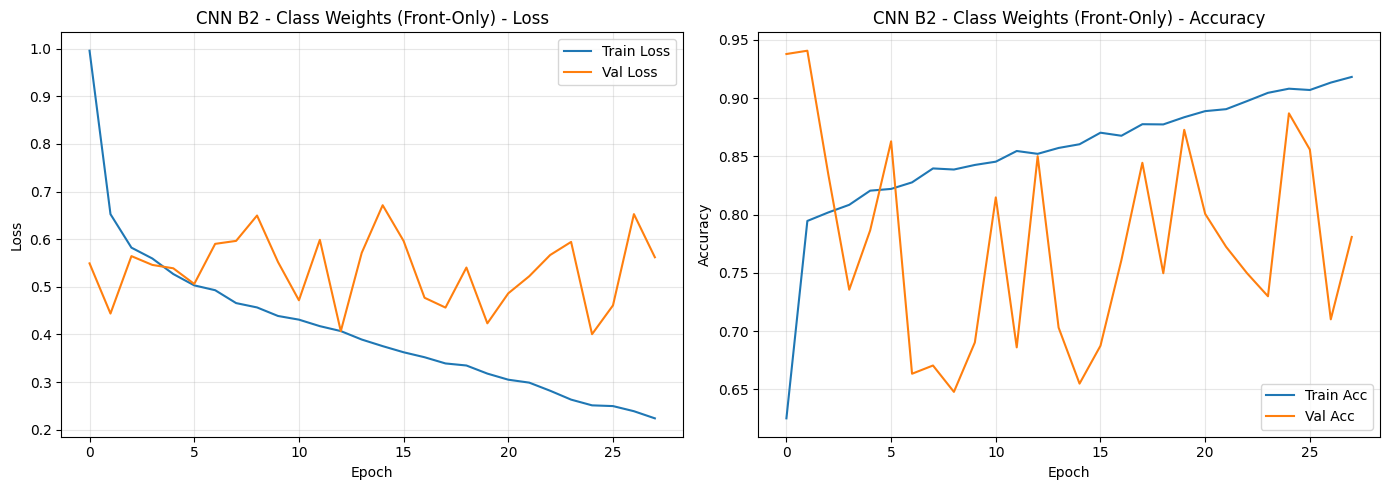

In [6]:
# B2: Class Weights
weights = get_class_weights(DATASET_DIR, device)
print(f"Class weights: {weights}")
criterion = nn.CrossEntropyLoss(weight=weights)

model = EmotionCNN(num_classes=NUM_CLASSES).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=8, min_lr=1e-7)

print("\nTraining CNN B2 - Class Weights (Front-Only)...")
history, best_epoch = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler,
    device, model_type="cnn", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "cnn_b2.pth"))

plot_training_history(history, "CNN B2 - Class Weights (Front-Only)")

EVALUASI B2 - CLASS WEIGHTS


Test Loss: 0.3314
Test Accuracy: 0.9006
Test Macro F1: 0.2396
Test Weighted F1: 0.9075

Classification Report:
              precision    recall  f1-score   support

     neutral       0.97      0.95      0.96       981
       happy       0.00      0.00      0.00        10
         sad       0.00      0.00      0.00        29
    negative       0.00      0.00      0.00        16

    accuracy                           0.90      1036
   macro avg       0.24      0.24      0.24      1036
weighted avg       0.91      0.90      0.91      1036



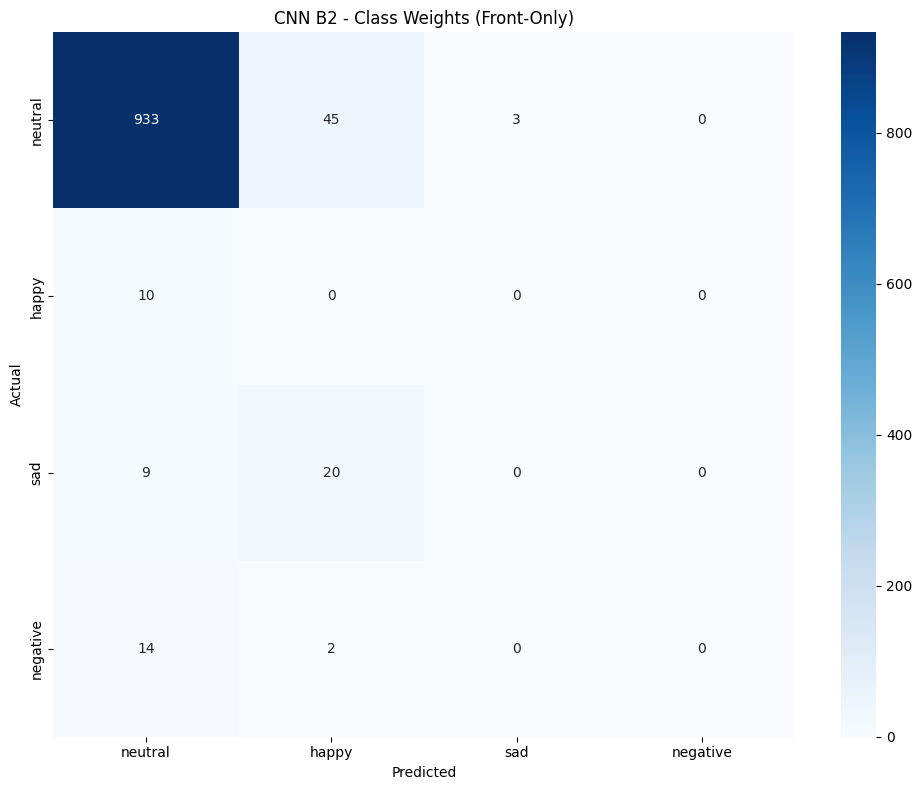

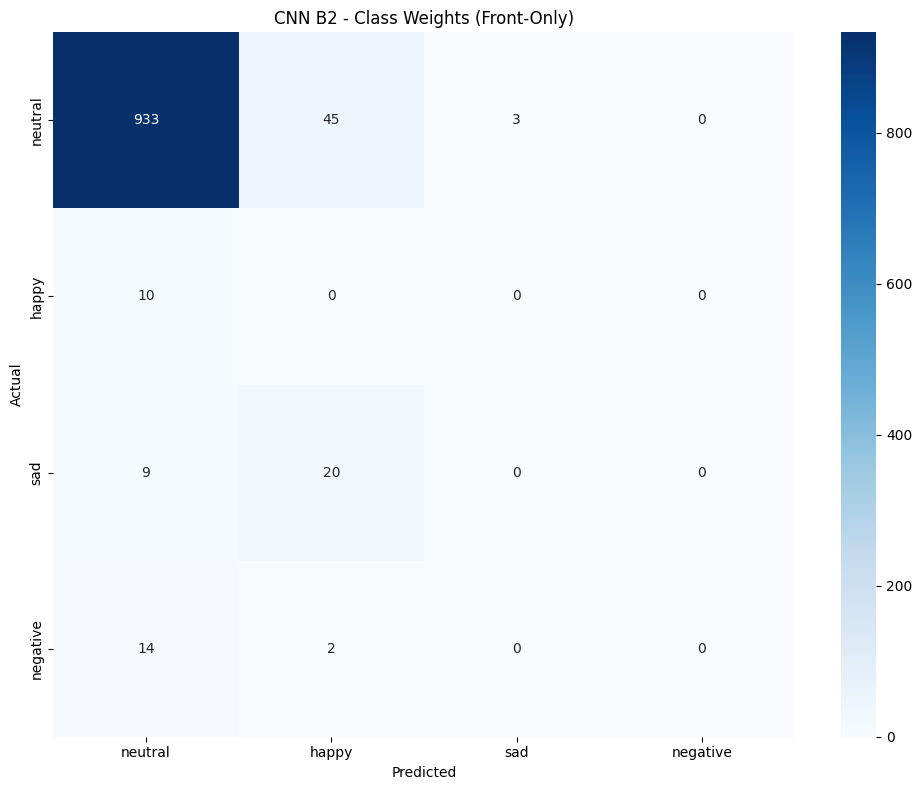

In [7]:
# Evaluate B2
model.load_state_dict(torch.load(OUTPUT_DIR / "cnn_b2.pth", map_location=device, weights_only=True))
print("=" * 60)
print("EVALUASI B2 - CLASS WEIGHTS")
print("=" * 60)
results_b2 = full_evaluation(model, test_loader, criterion, device, "cnn", EMOTIONS)
plot_confusion_matrix(results_b2["confusion_matrix"], "CNN B2 - Class Weights (Front-Only)", emotions=EMOTIONS)

## Skenario B3: Class Weights + Augmentasi

Train: 5834 | Val: 707 | Test: 1036
     neutral: 4192
       happy: 660
         sad: 382
    negative: 600
Augmented class weights: None


Model parameters: 26,998,692

Training CNN B3 - Weights + Augmentasi (Front-Only)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.0450     0.5812     0.6921    0.9349   0.2423   0.000100  (37.5s)


     2      0.7463     0.7403     0.4980    0.9392   0.2881   0.000100  (38.1s)


     3      0.6612     0.7650     0.5549    0.9293   0.2678   0.000100  (38.0s)


...

    29      0.1928     0.9306     0.6778    0.6931   0.3351   0.000050  (37.5s)


    30      0.1803     0.9344     0.5977    0.7426   0.3155   0.000050  (37.5s)


    31      0.1777     0.9371     0.9284    0.5884   0.2831   0.000050  (37.5s)


    32      0.1667     0.9383     0.6718    0.7100   0.3307   0.000050  (37.6s)


    33      0.1597     0.9431     0.7563    0.6803   0.3073   0.000050  (37.5s)

Early stopping at epoch 33. Best epoch: 18 (val_f1=0.3712)

Best: epoch 18, val_acc=0.7779, val_f1=0.3712
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/4class/cnn_b3.pth


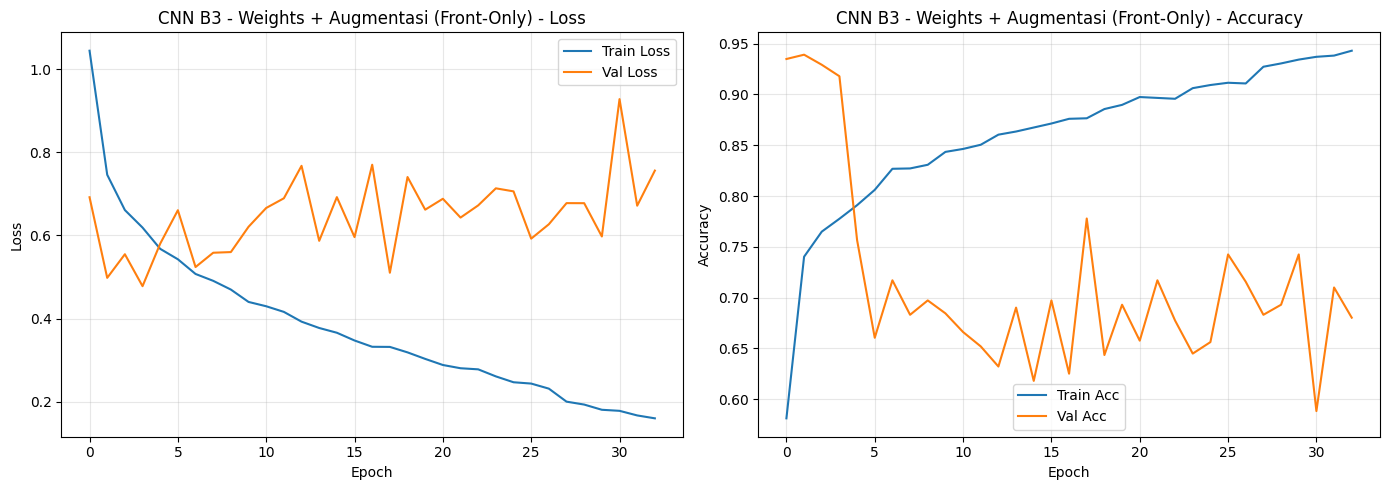

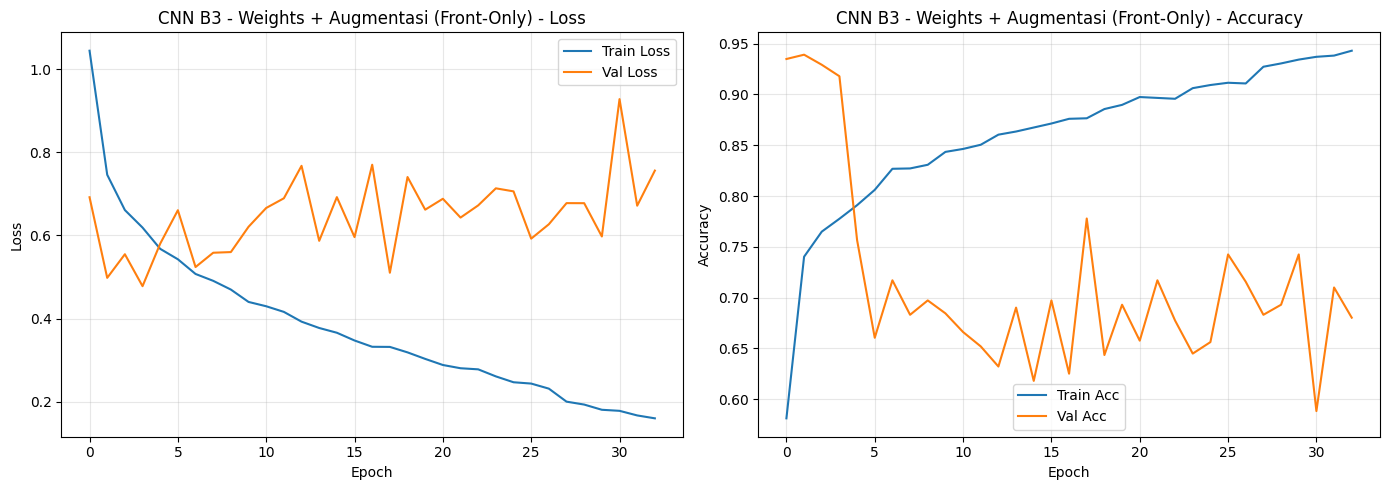

In [8]:
# B3: Weights + Augmentasi
train_loader_aug, _, _ = load_dataloaders(DATASET_AUG_DIR, BATCH_SIZE)
weights_aug = get_class_weights(DATASET_AUG_DIR, device)
print(f"Augmented class weights: {weights_aug}")
criterion = nn.CrossEntropyLoss(weight=weights_aug)

model = EmotionCNN(num_classes=NUM_CLASSES).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=8, min_lr=1e-7)

print("\nTraining CNN B3 - Weights + Augmentasi (Front-Only)...")
history, best_epoch = train_model(
    model, train_loader_aug, val_loader, criterion, optimizer, scheduler,
    device, model_type="cnn", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "cnn_b3.pth"))

plot_training_history(history, "CNN B3 - Weights + Augmentasi (Front-Only)")

EVALUASI B3 - WEIGHTS + AUGMENTASI


Test Loss: 0.3570
Test Accuracy: 0.9015
Test Macro F1: 0.2647
Test Weighted F1: 0.9058

Classification Report:
              precision    recall  f1-score   support

     neutral       0.96      0.95      0.95       981
       happy       0.00      0.00      0.00        10
         sad       0.22      0.07      0.11        29
    negative       0.00      0.00      0.00        16

    accuracy                           0.90      1036
   macro avg       0.29      0.25      0.26      1036
weighted avg       0.91      0.90      0.91      1036



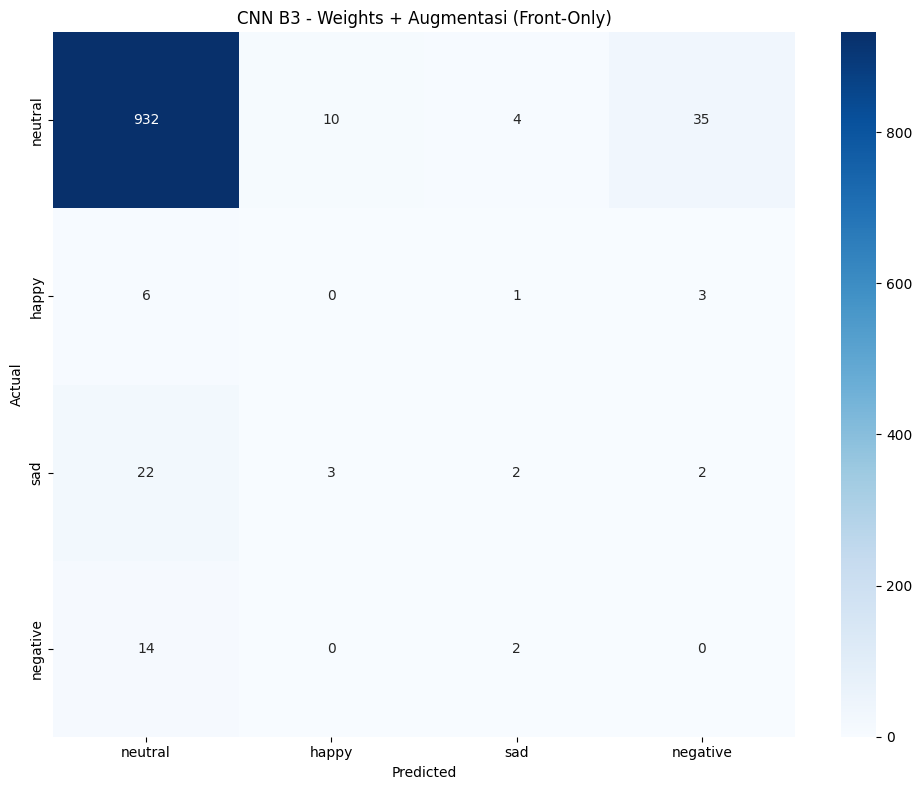

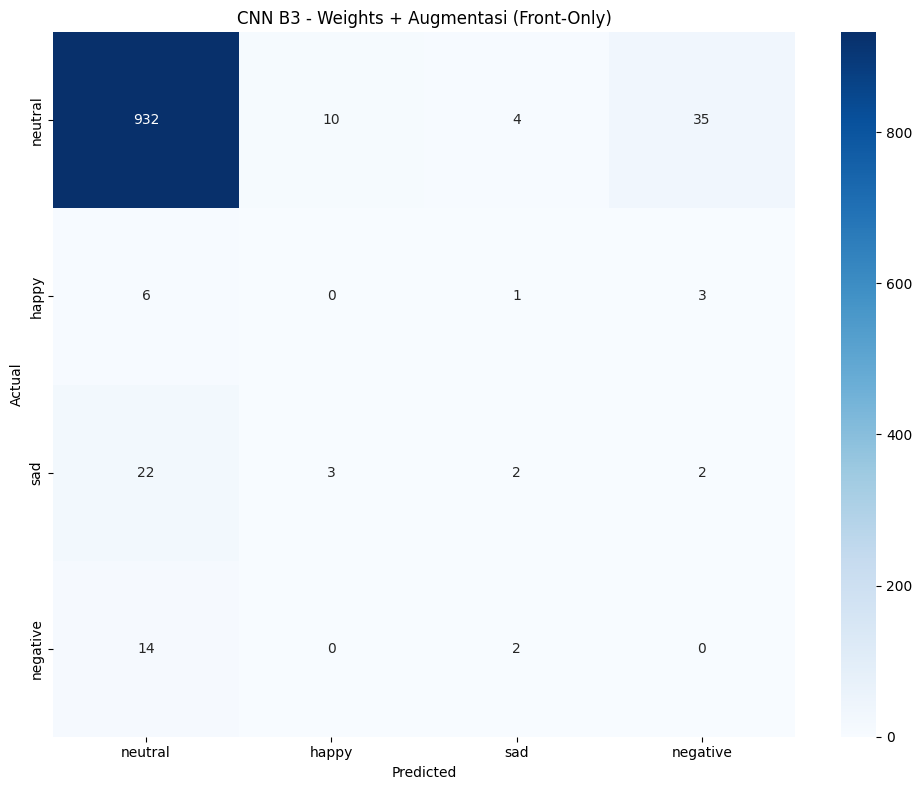

In [9]:
# Evaluate B3
model.load_state_dict(torch.load(OUTPUT_DIR / "cnn_b3.pth", map_location=device, weights_only=True))
print("=" * 60)
print("EVALUASI B3 - WEIGHTS + AUGMENTASI")
print("=" * 60)
results_b3 = full_evaluation(model, test_loader, criterion, device, "cnn", EMOTIONS)
plot_confusion_matrix(results_b3["confusion_matrix"], "CNN B3 - Weights + Augmentasi (Front-Only)", emotions=EMOTIONS)

## Perbandingan 3 Skenario

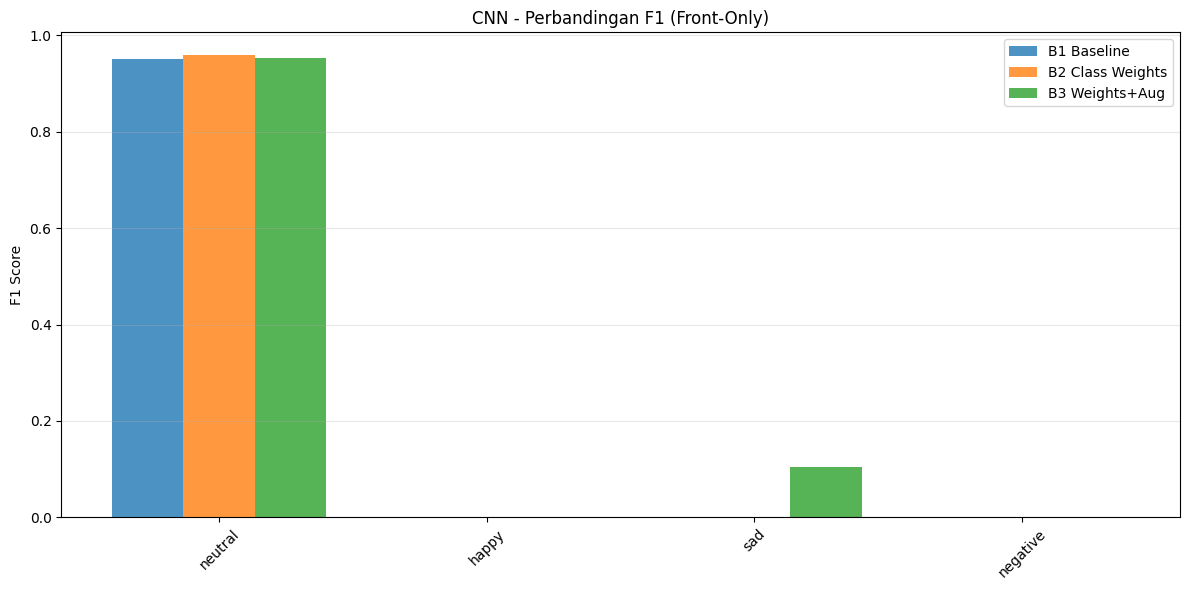

RINGKASAN CNN FRONT-ONLY
Skenario                    Accuracy   Macro F1  Weighted F1
----------------------------------------------------------------------
B1 Baseline                   0.8929     0.2379       0.9011
B2 Class Weights              0.9006     0.2396       0.9075
B3 Weights+Aug                0.9015     0.2647       0.9058

Saved to /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly/4class/cnn_results.json


In [10]:
# Perbandingan
all_results = {
    "B1 Baseline": results_b1,
    "B2 Class Weights": results_b2,
    "B3 Weights+Aug": results_b3,
}
plot_per_class_f1(all_results, "CNN - Perbandingan F1 (Front-Only)", emotions=EMOTIONS)

print("=" * 70)
print("RINGKASAN CNN FRONT-ONLY")
print("=" * 70)
print(f"{'Skenario':<25} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("-" * 70)
for name, r in all_results.items():
    print(f"{name:<25} {r['test_accuracy']:>10.4f} {r['test_macro_f1']:>10.4f} {r['test_weighted_f1']:>12.4f}")

results_save = {}
for name, r in all_results.items():
    results_save[name] = {
        "accuracy": float(r["test_accuracy"]),
        "macro_f1": float(r["test_macro_f1"]),
        "weighted_f1": float(r["test_weighted_f1"]),
    }
with open(OUTPUT_DIR / "cnn_results.json", "w") as f:
    json.dump(results_save, f, indent=2)
print(f"\nSaved to {OUTPUT_DIR / 'cnn_results.json'}")